In [7]:
import numpy as np

In [8]:
from configs import Configs
configs = Configs()
num_ics = 10
mesh = np.load("./data/train_valid/mesh_grid_coords.npy")
times = np.load("./data/train_valid/times.npy")
dt = times[1] - times[0]
num_times = times.shape[0]
solutions = np.load("./data/train_valid/solutions_grid_initials.npy", allow_pickle=True)
# solutions.shape --> [num_ics, num_times, 2, nx, ny]
Xs = np.zeros(
    ((num_times-1)*num_ics, 5, mesh.shape[0], mesh.shape[1])
)  # 5: phi, c, x, y, dt
Ys = np.zeros(
    ((num_times-1)*num_ics, 2, mesh.shape[0], mesh.shape[1])
)

for i in range(num_ics):
    Xs[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, :-1, 0, :, :]  # phi
    Xs[i*(num_times-1):(i+1)*(num_times-1), 1, :, :] = solutions[i, :-1, 1, :, :]  # c
    mesh_x_repeated = np.repeat(mesh[:, :, 0][np.newaxis, :, :], num_times-1, axis=0)
    Xs[i*(num_times-1):(i+1)*(num_times-1), 2, :, :] = mesh_x_repeated  # x
    mesh_y_repeated = np.repeat(mesh[:, :, 1][np.newaxis, :, :], num_times-1, axis=0)
    Xs[i*(num_times-1):(i+1)*(num_times-1), 3, :, :] = mesh_y_repeated  # y
    Xs[i*(num_times-1):(i+1)*(num_times-1), 4, :, :] = dt / configs.Tc  # dt normalized by Tc)

    Ys[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, 1:, 0, :, :]  # phi at next time step
    Ys[i*(num_times-1):(i+1)*(num_times-1), 1, :, :] = solutions[i, 1:, 1, :, :]  # c

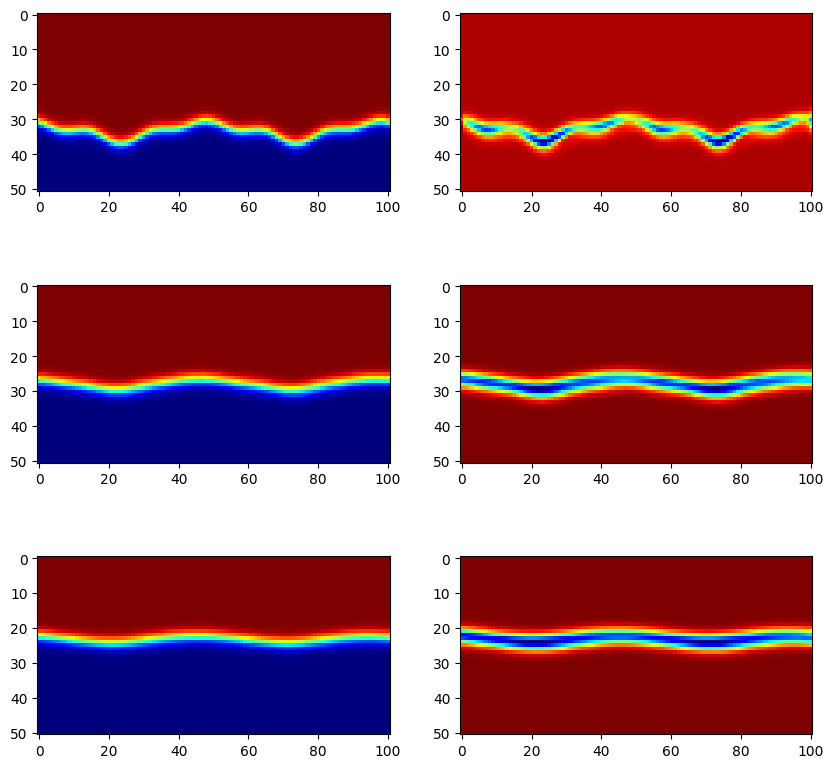

In [9]:
import matplotlib.pyplot as plt
ts = [0, 20, 40,]
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
for idx, t in enumerate(ts):
    x = Xs[t, 0, :, :]
    y = Ys[t, 0, :, :]
    diff = y - x
    ax = axes[idx, 0]
    ax.imshow(x, cmap='jet')
    ax = axes[idx, 1]
    ax.imshow(diff, cmap='jet')

In [10]:
np.savez(
    "./data/train_valid/dataset_2d_complete.npz",
    meshes=mesh/configs.Lc,
    times=times/configs.Tc,
    Xs=Xs,
    Ys=Ys,
)